# Supplementary Material:
# Vapor-Liquid calculations based on the SAFT-VR Mie EoS for Isobaric Vapor-Liquid Equilibria of Dibutyl Ether + Butan-1-ol Binary Mixture.

*Juan M. Uceda, Marcela Cartes and Andrés Mejía*

This notebook is used for modeling the vapor - liquid equilibria (VLE) based on the $\phi - \phi$ approach. Both the vapor and the liquid phases are modeled using the SAFT-VR Mie proposed by Lafitte et al.
This notebook uses an external Excel file (dbe-1butanol.xlsx) which contains the experimental data and the SGTPy suite, which is free download at https://pypi.python.org/pypi/sgtpy/

For further details and thermodynamical properties of pure fluids, the reader is redirected to “Measurements and Theoretical Modeling of Isobaric Vapor-Liquid Equilibria and Dynamic Viscosity for the Dibutyl Ether and Butan-1-ol Binary Mixture” by J. M. Uceda, M. Cartes and A. Mejía. Journal of Chemical & Engineering Data 2025, 70, 6, 2371–2385, - (https://doi.org/10.1021/acs.jced.4c00725)

In [1]:
#read experimental VLE data
import pandas as pd
dfVLE50 = pd.read_excel('dbe-1butanol.xlsx', sheet_name='VLE_50')
dfVLE75 = pd.read_excel('dbe-1butanol.xlsx', sheet_name='VLE_75')
dfVLE94 = pd.read_excel('dbe-1butanol.xlsx', sheet_name='VLE_94')
#50.00 kPa
Texp50 = dfVLE50['T/K'].to_numpy()
pexp50 = dfVLE50['p/kPa'].to_numpy()
x1exp50 = dfVLE50['x1'].to_numpy()
y1exp50 = dfVLE50['y1'].to_numpy()
#75.00 kPa
Texp75 = dfVLE75['T/K'].to_numpy()
pexp75 = dfVLE75['p/kPa'].to_numpy()
x1exp75 = dfVLE75['x1'].to_numpy()
y1exp75 = dfVLE75['y1'].to_numpy()
#94.00 kPa
Texp94 = dfVLE94['T/K'].to_numpy()
pexp94 = dfVLE94['p/kPa'].to_numpy()
x1exp94 = dfVLE94['x1'].to_numpy()
y1exp94 = dfVLE94['y1'].to_numpy()

In [2]:
dfVLE50.head(n=24)

,T/K,p/kPa,x1,y1
0,371.907315,50,0.000,0.000
1,370.920000,50,0.102,0.120
2,370.380000,50,0.150,0.161
3,370.630000,50,0.197,0.195
4,369.920000,50,0.246,0.227
5,369.430000,50,0.294,0.256
6,369.660000,50,0.342,0.280
7,369.680000,50,0.392,0.305
8,369.840000,50,0.444,0.328
9,370.260000,50,0.497,0.355


In [3]:
dfVLE75.head(n=24)

,T/K,p/kPa,x1,y1
0,382.298757,75,0.000,0.000
1,381.050000,75,0.102,0.110
2,380.880000,75,0.150,0.148
3,380.760000,75,0.198,0.181
4,380.540000,75,0.248,0.212
5,380.210000,75,0.294,0.237
6,380.350000,75,0.343,0.261
7,380.460000,75,0.395,0.285
8,380.900000,75,0.445,0.309
9,381.310000,75,0.498,0.334


In [4]:
dfVLE94.head(n=24)

,T/K,p/kPa,x1,y1
0,388.439814,94,0.000,0.000
1,387.250000,94,0.102,0.105
2,387.100000,94,0.151,0.142
3,386.790000,94,0.198,0.174
4,386.520000,94,0.247,0.203
5,386.400000,94,0.295,0.229
6,386.500000,94,0.343,0.254
7,386.760000,94,0.394,0.277
8,387.210000,94,0.444,0.300
9,387.550000,94,0.495,0.325


In [5]:
import numpy as np
#50.00 kPa
Xexp50 = np.array([x1exp50, 1-x1exp50])
Yexp50 = np.array([y1exp50, 1-y1exp50])
datavle50 = (Xexp50, Yexp50, Texp50, pexp50)
#75.00 kPa
Xexp75 = np.array([x1exp75, 1-x1exp75])
Yexp75 = np.array([y1exp75, 1-y1exp75])
datavle75 = (Xexp75, Yexp75, Texp75, pexp75)
#94.00 kPa
Xexp94 = np.array([x1exp94, 1-x1exp94])
Yexp94 = np.array([y1exp94, 1-y1exp94])
datavle94 = (Xexp94, Yexp94, Texp94, pexp94)

In [6]:
import numpy as np
from sgtpy import component, mixture, saftvrmie
DBE = component('DBE', ms=2.9326, sigma=4.3581, eps=363.107, lambda_r=17.4657, lambda_a=6, eAB=2500, rcAB=0.280, 
                sites=[0,0,1], npol=4.3989, mupol=1.17, Mw=130.23)
nbOH = component('nbOH', ms=2.4614, sigma=3.7704, eps=266.49, lambda_r=11.338, lambda_a=6, eAB=2910.05, rcAB=0.3042, 
                 rdAB=0.4, npol=0, mupol = 1.66, sites=[1,0,1], Mw=74.12)
mix = mixture(DBE, nbOH)

In [7]:
datavle50 = (Xexp50, Yexp50, Texp50, pexp50*1000)
datavle75 = (Xexp75, Yexp75, Texp75, pexp75*1000)
datavle94 = (Xexp94, Yexp94, Texp94, pexp94*1000)

In [8]:
from sgtpy.fit import fit_asso
x0 = np.array([0, 0])
min_options = {'method':'Nelder-Mead'}
params50 = fit_asso(x0, mix, datavle=datavle50, minimize_options=min_options)
print(params50)

 final_simplex: (array([[0.00465241, 0.0308035 ],
       [0.00465671, 0.03076878],
       [0.00464683, 0.03087699]]), array([0.00071088, 0.00071088, 0.00071088]))
           fun: 0.0007108786931961543
       message: 'Optimization terminated successfully.'
          nfev: 83
           nit: 44
        status: 0
       success: True
             x: array([0.00465241, 0.0308035 ])


In [9]:
params75 = fit_asso(x0, mix, datavle=datavle75, minimize_options=min_options)
print(params75)

 final_simplex: (array([[ 0.0128079 , -0.03536705],
       [ 0.0128167 , -0.03544171],
       [ 0.01280564, -0.03537565]]), array([0.00068312, 0.00068312, 0.00068312]))
           fun: 0.0006831191760580215
       message: 'Optimization terminated successfully.'
          nfev: 84
           nit: 44
        status: 0
       success: True
             x: array([ 0.0128079 , -0.03536705])


In [10]:
params94 = fit_asso(x0, mix, datavle=datavle94, minimize_options=min_options)
print(params94)

 final_simplex: (array([[ 0.01490206, -0.04516922],
       [ 0.01489761, -0.04515613],
       [ 0.01491392, -0.04525899]]), array([0.00075101, 0.00075101, 0.00075101]))
           fun: 0.0007510140899284841
       message: 'Optimization terminated successfully.'
          nfev: 88
           nit: 46
        status: 0
       success: True
             x: array([ 0.01490206, -0.04516922])


In [11]:
def azeotrope(Kij, p, T0):
    mix.kij_saft(Kij)
    eos = saftvrmie(mix)
    X0 = np.array([0.5, 0.5])
    Y0 = X0
    Y, T = bubbleTy(Y0, T0, X0, p, eos)
    while abs(Y[0]-X0[0])>=1.0e-04:
        X0 = Y
        Y0 = X0
        Y, T = bubbleTy(Y0, T0, X0, p, eos)
    return Y, T

In [12]:
def gammaSAFTVRMie(component1, component2, Texp, p, Xexp, matKij, matLij):
    '''
    Calculate the activity coefficients according to SAFT-VR Mie's approach
    '''
    import math
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    Na = 6.022142e23  # Avogadro's number, mol^{-1}
    R = Na*kb
    n = len(Texp)
    gamma1 = np.zeros_like(Texp)
    gamma2 = np.zeros_like(Texp)
    gE = np.zeros_like(Texp)
    for i in range(n):
        eos1 = saftvrmie(component1)
        eos2 = saftvrmie(component2)
        lnphi1, vl1 = eos1.logfug(Texp[i], p, 'L')
        lnphi2, vl2 = eos2.logfug(Texp[i], p, 'L')
        phi1 = np.exp(lnphi1)
        phi2 = np.exp(lnphi2)
        mix = mixture(component1, component2)
        mix.kij_saft(matKij)
        mix.lij_saft(matLij)
        eosmix = saftvrmie(mix)
        lnphimix, vmix = eosmix.logfugef(Xexp[:,i], Texp[i], p, 'L')
        phimix1 = np.exp(lnphimix[0])
        phimix2 = np.exp(lnphimix[1])
        gamma1[i] = phimix1/phi1
        gamma2[i] = phimix2/phi2
        gE[i] = Xexp[0,i]*np.log(gamma1[i])+Xexp[1,i]*np.log(gamma2[i])
    
    return gamma1, gamma2, gE

In [13]:
X = np.array([np.linspace(0.00, 1.00, num=101), 
              np.linspace(1.00, 0.00, num=101)])
n = len(X[0])

In [14]:
from sgtpy.equilibrium import bubbleTy
Kij = np.array([[0, params50.x[0]], 
                  [params50.x[0], 0]])
Lij = np.array([[0, params50.x[1]], 
                  [params50.x[1], 0]])
mix.kij_saft(Kij)
mix.lij_saft(Lij)
eos = saftvrmie(mix)
p = 50000
T0 = 380
Ysaft50 = np.zeros_like(X)
Tsaft50 = np.zeros_like(X[0])
for i in range(n):
    Ysaft50[:,i], Tsaft50[i] = bubbleTy(X[:,i], T0, X[:,i], p, eos)

z = len(Xexp50[0])  
Ysaftexp50 = np.zeros_like(Xexp50)
Tsaftexp50 = np.zeros(z)
for i in range(z):
    Ysaftexp50[:,i], Tsaftexp50[i] = bubbleTy(Xexp50[:,i], T0, Xexp50[:,i], p, eos)

In [15]:
gam1saft50, gam2saft50, gEsaft50 = gammaSAFTVRMie(DBE, nbOH, Tsaft50, 50000, X, Kij, Lij)
gam1saftexp50, gam2saftexp50, gEsaftexp50 = gammaSAFTVRMie(DBE, nbOH, Tsaftexp50, 50000, Xexp50, Kij, Lij)

In [16]:
Zaz50, Taz50 = azeotrope(Kij, p, T0)
print("Azeotropic conditions at p=", p, "kPa")
print("==================================================")
print("Comp.:", Zaz50)
print("Temp./K:", Taz50)

Azeotropic conditions at p= 50000 kPa
Comp.: [0.24134379 0.75865621]
Temp./K: 370.2526202179451


In [17]:
#bubble-point calculation
from sgtpy.equilibrium import bubblePy
Ysaftexp = np.zeros_like(Xexp50)
psaftexp = np.zeros_like(Xexp50[0])
m = len(Xexp50[0])
for i in range(m):
    Ysaftexp[:,i], psaftexp[i] = bubblePy(Yexp50[:,i], pexp50[i]*1000, Xexp50[:,i], Texp50[i], eos)

dpsaft50 = psaftexp/1000-pexp50
dy1saft50 = Ysaftexp[0]-Yexp50[0]
AADp = 1/len(pexp50)*np.sum(abs(psaftexp/1000-pexp50))
AADy1 = 1/len(pexp50)*np.sum(abs(Ysaftexp[0]-Yexp50[0]))
print("Bubble-point statistics at p=", p, "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADy1", AADy1)

Bubble-point statistics at p= 50000 kPa
AADp/kPa 0.6937159794719387
AADy1 0.010786681877618675


In [18]:
#dew-point calculation
from sgtpy.equilibrium import dewPx
Xsaftexp = np.zeros_like(Xexp50)
psaftexp = np.zeros_like(Xexp50[0])
m = len(Xexp50[0])
for i in range(m):
    Xsaftexp[:,i], psaftexp[i] = dewPx(Xexp50[:,i], pexp50[i]*1000, Yexp50[:,i], Texp50[i], eos)

AADp = 1/len(pexp50)*np.sum(abs(psaftexp/1000-pexp50))
AADx1 = 1/len(pexp50)*np.sum(abs(Xsaftexp[0]-Xexp50[0]))
print("Dew-point statistics at p=", p, "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADy1", AADx1)

Dew-point statistics at p= 50000 kPa
AADp/kPa 0.8532698092272598
AADy1 0.016269942256851865


In [19]:
Kij = np.array([[0, params75.x[0]], 
                  [params75.x[0], 0]])
Lij = np.array([[0, params75.x[1]], 
                  [params75.x[1], 0]])
mix.kij_saft(Kij)
mix.lij_saft(Lij)
eos = saftvrmie(mix)
p = 75000
T0 = 390
Ysaft75 = np.zeros_like(X)
Tsaft75 = np.zeros_like(X[0])
for i in range(n):
    Ysaft75[:,i], Tsaft75[i] = bubbleTy(X[:,i], T0, X[:,i], p, eos)

z = len(Xexp75[0])  
Ysaftexp75 = np.zeros_like(Xexp75)
Tsaftexp75 = np.zeros(z)
for i in range(z):
    Ysaftexp75[:,i], Tsaftexp75[i] = bubbleTy(Xexp75[:,i], T0, Xexp75[:,i], p, eos)

In [20]:
gam1saft75, gam2saft75, gEsaft75 = gammaSAFTVRMie(DBE, nbOH, Tsaft75, 75000, X, Kij, Lij)
gam1saftexp75, gam2saftexp75, gEsaftexp75 = gammaSAFTVRMie(DBE, nbOH, Tsaftexp75, 75000, Xexp75, Kij, Lij)

In [21]:
Zaz75, Taz75 = azeotrope(Kij, p, T0)
print("Azeotropic conditions at p=", p, "kPa")
print("==================================================")
print("Comp.:", Zaz75)
print("Temp./K:", Taz75)

Azeotropic conditions at p= 75000 kPa
Comp.: [0.21218412 0.78781588]
Temp./K: 380.7628393986155


In [22]:
#bubble-point calculation
Ysaftexp = np.zeros_like(Xexp75)
psaftexp = np.zeros_like(Xexp75[0])
m = len(Xexp75[0])
for i in range(m):
    Ysaftexp[:,i], psaftexp[i] = bubblePy(Yexp75[:,i], pexp75[i]*1000, Xexp75[:,i], Texp75[i], eos)

dpsaft75 = psaftexp/1000-pexp75
dy1saft75 = Ysaftexp[0]-Yexp75[0]
AADp = 1/len(pexp75)*np.sum(abs(psaftexp/1000-pexp75))
AADy1 = 1/len(pexp75)*np.sum(abs(Ysaftexp[0]-Yexp75[0]))
print("Bubble-point statistics at p=", p, "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADy1", AADy1)

Bubble-point statistics at p= 75000 kPa
AADp/kPa 0.9429151282948725
AADy1 0.011748485611382318


In [23]:
#dew-point calculation
Xsaftexp = np.zeros_like(Xexp75)
psaftexp = np.zeros_like(Xexp75[0])
m = len(Xexp75[0])
for i in range(m):
    Xsaftexp[:,i], psaftexp[i] = dewPx(Xexp75[:,i], pexp75[i]*1000, Yexp75[:,i], Texp75[i], eos)

AADp = 1/len(pexp75)*np.sum(abs(psaftexp/1000-pexp75))
AADx1 = 1/len(pexp75)*np.sum(abs(Xsaftexp[0]-Xexp75[0]))
print("Dew-point statistics at p=", p, "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADx1", AADx1)

Dew-point statistics at p= 75000 kPa
AADp/kPa 1.2331097814010483
AADx1 0.017880502341424784


In [24]:
Kij = np.array([[0, params94.x[0]], 
                  [params94.x[0], 0]])
Lij = np.array([[0, params94.x[1]], 
                  [params94.x[1], 0]])
mix.kij_saft(Kij)
mix.lij_saft(Lij)
eos = saftvrmie(mix)
p = 94000
T0 = 395
Ysaft94 = np.zeros_like(X)
Tsaft94 = np.zeros_like(X[0])
for i in range(n):
    Ysaft94[:,i], Tsaft94[i] = bubbleTy(X[:,i], T0, X[:,i], p, eos)

z = len(Xexp94[0])  
Ysaftexp94 = np.zeros_like(Xexp94)
Tsaftexp94 = np.zeros(z)
for i in range(z):
    Ysaftexp94[:,i], Tsaftexp94[i] = bubbleTy(Xexp94[:,i], T0, Xexp94[:,i], p, eos)

In [25]:
gam1saft94, gam2saft94, gEsaft94 = gammaSAFTVRMie(DBE, nbOH, Tsaft94, 94000, X, Kij, Lij)
gam1saftexp94, gam2saftexp94, gEsaftexp94 = gammaSAFTVRMie(DBE, nbOH, Tsaftexp94, 94000, Xexp94, Kij, Lij)

In [26]:
azeotrope(Kij, p, T0)

(array([0.20246282, 0.79753718]), 386.9353743963612)

In [27]:
Zaz94, Taz94 = azeotrope(Kij, p, T0)
print("Azeotropic conditions at p=", p, "kPa")
print("===========================================================")
print("Comp.:", Zaz94)
print("Temp./K:", Taz94)

Azeotropic conditions at p= 94000 kPa
Comp.: [0.20246282 0.79753718]
Temp./K: 386.9353743963612


In [28]:
#bubble-point calculation
Ysaftexp = np.zeros_like(Xexp94)
psaftexp = np.zeros_like(Xexp94[0])
m = len(Xexp94[0])
for i in range(m):
    Ysaftexp[:,i], psaftexp[i] = bubblePy(Yexp94[:,i], pexp94[i]*1000, Xexp94[:,i], Texp94[i], eos)

dpsaft94 = psaftexp/1000-pexp94
dy1saft94 = Ysaftexp[0]-Yexp94[0]
AADp = 1/len(pexp94)*np.sum(abs(psaftexp/1000-pexp94))
AADy1 = 1/len(pexp94)*np.sum(abs(Ysaftexp[0]-Yexp94[0]))
print("Bubble-point statistics at p=", p, "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADy1", AADy1)

Bubble-point statistics at p= 94000 kPa
AADp/kPa 1.3967996100577302
AADy1 0.011485419669924612


In [29]:
#dew-point calculation
Xsaftexp = np.zeros_like(Xexp94)
psaftexp = np.zeros_like(Xexp94[0])
m = len(Xexp94[0])
for i in range(m):
    Xsaftexp[:,i], psaftexp[i] = dewPx(Xexp94[:,i], pexp94[i]*1000, Yexp94[:,i], Texp94[i], eos)

AADp = 1/len(pexp94)*np.sum(abs(psaftexp/1000-pexp94))
AADx1 = 1/len(pexp94)*np.sum(abs(Xsaftexp[0]-Xexp94[0]))
print(AADp)
print(AADx1)
print("Dew-point statistics at p=", p, "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADx1", AADx1)

1.6595798879837353
0.017367772550019245
Dew-point statistics at p= 94000 kPa
AADp/kPa 1.6595798879837353
AADx1 0.017367772550019245


In [30]:
xAz = np.array([Zaz50[0], Zaz75[0], Zaz94[0]])
TAz = np.array([Taz50, Taz75, Taz94])

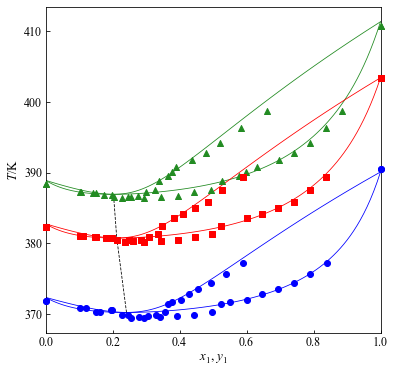

In [31]:
from matplotlib import rc
import matplotlib.pylab as plt
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize = (6, 6))
plt.tick_params(direction='in')
plt.scatter(Yexp94[0], Texp94, marker='^', color='ForestGreen', clip_on=False, zorder=10, label='_nolegend_')
plt.scatter(Xexp94[0], Texp94, marker='^', color='ForestGreen', clip_on=False, zorder=10)
plt.scatter(Yexp75[0], Texp75, marker='s', color='red', clip_on=False, zorder=10, label='_nolegend_')
plt.scatter(Xexp75[0], Texp75, marker='s', color='red', clip_on=False, zorder=10)
plt.scatter(Yexp50[0], Texp50, color='blue', clip_on=False, zorder=10, label='_nolegend_')
plt.scatter(Xexp50[0], Texp50, color='blue', clip_on=False, zorder=10)
plt.plot(X[0], Tsaft94, linestyle='solid', linewidth=0.8, color='ForestGreen', label='_nolegend_')
plt.plot(Ysaft94[0], Tsaft94, linestyle='solid', linewidth=0.8, color='ForestGreen', label='_nolegend_')
plt.plot(X[0], Tsaft75, linestyle='solid', linewidth=0.8, color='red', label='_nolegend_')
plt.plot(Ysaft75[0], Tsaft75, linestyle='solid', linewidth=0.8, color='red', label='_nolegend_')
plt.plot(X[0], Tsaft50, linestyle='solid', linewidth=0.8, color='blue', label='_nolegend_')
plt.plot(Ysaft50[0], Tsaft50, linestyle='solid', linewidth=0.8, color='blue', label='_nolegend_')
plt.plot(xAz, TAz, linestyle='dashed', color='black', linewidth=0.8)
plt.xlabel('$x_{1}$, $y_{1}$', fontsize=13)
plt.xlim([0,1])
plt.ylabel('$T$/K', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [32]:
fig.savefig("dbe-nbOH_VLE.pdf", bbox_inches='tight')

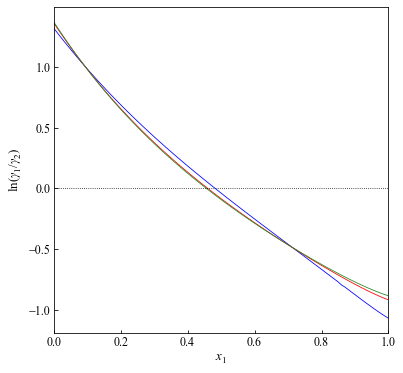

In [33]:
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.plot(X[0], np.log(gam1saft50/gam2saft50), linestyle='solid', linewidth=0.8, color='blue', label='_nolegend_')
plt.plot(X[0], np.log(gam1saft75/gam2saft75), linestyle='solid', linewidth=0.8, color='red', label='_nolegend_')
plt.plot(X[0], np.log(gam1saft94/gam2saft94), linestyle='solid', linewidth=0.8, color='ForestGreen', label='_nolegend_')
plt.axhline(y=0, linestyle='dotted', linewidth=0.8, color='black')
plt.xlim([0, 1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('$x_{1}$', fontsize=13)
plt.ylabel('$\mathrm{ln}(\gamma_{1}/\gamma_{2})$', fontsize=13)
plt.show()

In [34]:
fig.savefig("dbe-nbOH_ratio.pdf", bbox_inches='tight')

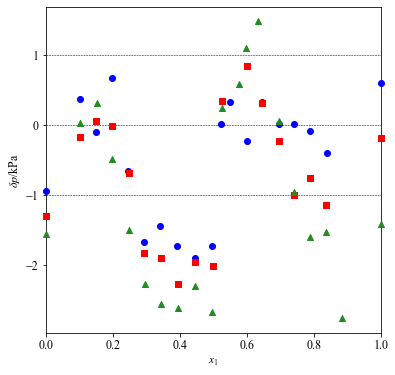

In [35]:
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.scatter(Xexp50[0], dpsaft50, color='blue', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], dpsaft75, marker='s', color='red', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], dpsaft94, marker='^', color='ForestGreen', clip_on=False, zorder=10)
plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=-1.0, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=1.0, linestyle='dashed', color='black', linewidth=0.5)
plt.xlim([0, 1])
plt.xlabel('$x_{1}$')
plt.ylabel('$\delta p$/kPa')
plt.show()

In [36]:
fig.savefig("dbe-nbOH_respSAFT+leg.pdf", bbox_inches='tight')

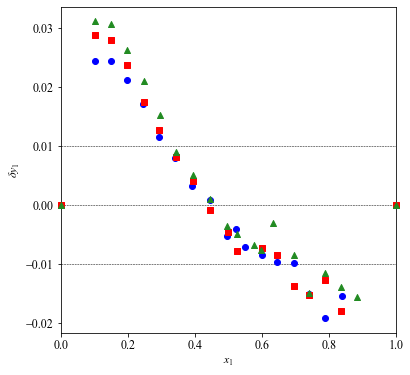

In [37]:
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.scatter(Xexp50[0], dy1saft50, color='blue', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], dy1saft75, marker='s', color='red', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], dy1saft94, marker='^', color='ForestGreen', clip_on=False, zorder=10)
plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=-0.01, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=0.01, linestyle='dashed', color='black', linewidth=0.5)
plt.xlim([0, 1])
plt.xlabel('$x_{1}$')
plt.ylabel('$\delta y_{1}$')
plt.show()

In [38]:
fig.savefig("dbe-nbOH_resy1SAFT+leg.pdf", bbox_inches='tight')

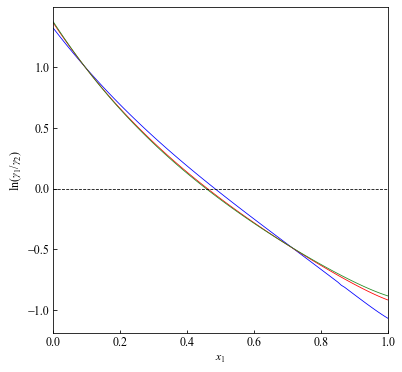

In [39]:
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.plot(X[0], np.log(gam1saft50/gam2saft50), linestyle='solid', linewidth=0.8, color='blue')
plt.plot(X[0], np.log(gam1saft75/gam2saft75), linestyle='solid', linewidth=0.8, color='red')
plt.plot(X[0], np.log(gam1saft94/gam2saft94), linestyle='solid', linewidth=0.8, color='ForestGreen')
plt.axhline(y=0, linestyle='dashed', linewidth=0.8, color='black')
plt.xlabel('$x_{1}$')
plt.xlim([0, 1])
plt.ylabel('$\mathrm{ln}(\gamma_{1}/\gamma_{2})$')
plt.show()

In [40]:
fig.savefig("global_dbe-nbOH_ratio.pdf", bbox_inches='tight')

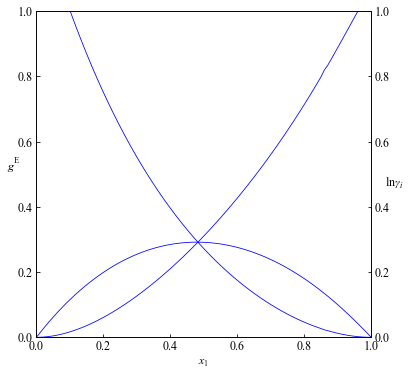

In [41]:
fig, ax1 = plt.subplots(figsize=(6, 6))
ax1.tick_params(direction='in')
ax1.set_xlabel('$x_{1}$')
ax1.set_ylabel('$g^{\mathrm{E}}$', rotation='horizontal')
ax1.plot(X[0], gEsaft50, linestyle='solid', color='blue', linewidth=0.8)
ax1.set_ylim([0, 1.0])

ax2 = ax1.twinx()
ax2.tick_params(direction='in')
ax2.plot(X[0], np.log(gam1saft50), X[0], np.log(gam2saft50), linestyle='solid', color='blue', linewidth=0.8)
ax2.set_ylabel('$\mathrm{ln}\gamma_{i}$', rotation='horizontal')
ax2.set_ylim([0, 1.0])

plt.xlim([0, 1])
plt.show()

In [42]:
fig.savefig("dbe-nbOH_gam50_saft.pdf", bbox_inches='tight')

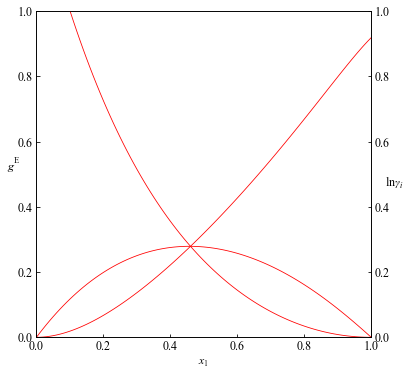

In [43]:
fig, ax1 = plt.subplots(figsize=(6, 6))
ax1.tick_params(direction='in')
ax1.set_xlabel('$x_{1}$')
ax1.set_ylabel('$g^{\mathrm{E}}$', rotation='horizontal')
ax1.plot(X[0], gEsaft75, linestyle='solid', color='red', linewidth=0.8)
ax1.set_ylim([0, 1.0])

ax2 = ax1.twinx()
ax2.tick_params(direction='in')
ax2.plot(X[0], np.log(gam1saft75), X[0], np.log(gam2saft75), linestyle='solid', color='red', linewidth=0.8)
ax2.set_ylabel('$\mathrm{ln}\gamma_{i}$', rotation='horizontal')
ax2.set_ylim([0, 1.0])

plt.xlim([0, 1])
plt.show()

In [44]:
fig.savefig("dbe-nbOH_gam75_saft.pdf", bbox_inches='tight')

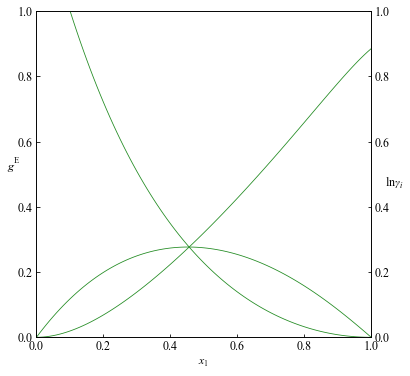

In [45]:
fig, ax1 = plt.subplots(figsize=(6, 6))
ax1.tick_params(direction='in')
ax1.set_xlabel('$x_{1}$')
ax1.set_ylabel('$g^{\mathrm{E}}$', rotation='horizontal')
ax1.plot(X[0], gEsaft94, linestyle='solid', color='ForestGreen', linewidth=0.8)
ax1.set_ylim([0, 1.0])

ax2 = ax1.twinx()
ax2.tick_params(direction='in')
ax2.plot(X[0], np.log(gam1saft94), X[0], np.log(gam2saft94), linestyle='solid', color='ForestGreen', linewidth=0.8)
ax2.set_ylabel('$\mathrm{ln}\gamma_{i}$', rotation='horizontal')
ax2.set_ylim([0, 1.0])

plt.xlim([0, 1])
plt.show()

In [46]:
fig.savefig("dbe-nbOH_gam94_saft.pdf", bbox_inches='tight')